## 0. Setup & Imports

In [1]:
import os
import re
import shutil
import tempfile
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
BASE = r'C:/Users/mfg0631/OneDrive - AUT University/SafeSwim'
DATA = f'{BASE}/Dataset'

SOE_DATA_PATH   = f'{DATA}/SoE_data.xlsx'
SWIM_DATA_PATH  = f'{DATA}/swim_spot_data.xlsx'
FLOW_MEAN_PATH  = f'{DATA}/20260602_PID293235_MINZ_Flow_Mean.csv'
FLOW_MAX_PATH   = f'{DATA}/20260602_PID293235_MINZ_Flow Max.csv'
FLOW_MIN_PATH   = f'{DATA}/20260602_PID293235_MINZ_Flow_Min.csv'
RAIN_TOTAL_PATH = f'{DATA}/20260610_PID290009_MINZ_RFTOTAL.csv'
RAIN_HR_PATH    = f'{DATA}/20260610_PID290009_MINZ_RainfallInten1hr.csv'
WT_MEAN_PATH = f'{DATA}/20260602_PID293235_MINZ_WT_Mean.csv'
WT_MAX_PATH  = f'{DATA}/20260602_PID293235_MINZ_WT_Max.csv'
WT_MIN_PATH  = f'{DATA}/20260602_PID293235_MINZ_WT_Min.csv'

# Oroua at Barrows Road excluded: WT data only covers 2000-2002, entirely before START_DATE
WT_GAUGES = [
    'Oroua at Almadale Slackline',
]
WT_SLUG = {
    'Oroua at Almadale Slackline': 'almadale',
}

ECOLI_SOURCE_CONFIGS = [
    {
        'source': 'SoE_data.xlsx',
        'path': SOE_DATA_PATH,
        'sheet_name': 'User hts file',
        'site_names': ['Oroua at Almadale Slackline'],
        'priority': 0,
    },
    {
        'source': 'swim_spot_data.xlsx',
        'path': SWIM_DATA_PATH,
        'sheet_name': 'Recreational Water Quality',
        'site_names': ['Oroua at Almadale'],
        'priority': 1,
    },
]

FLOW_GAUGES = [
    'Oroua at Almadale Slackline',
]
FLOW_SLUG = {
    'Oroua at Almadale Slackline': 'almadale',
}

RAIN_GAUGES = [
    'Oroua at Rangiwahia',
    'Makino at Cheltenham',
    'Makino at Halcombe Road',
    'Mangaone at Valley Road',
]
RAIN_SLUG = {
    'Oroua at Rangiwahia':      'rangiwahia',
    'Makino at Cheltenham':     'cheltenham',
    'Makino at Halcombe Road':  'halcombe',
    'Mangaone at Valley Road':  'mangaone_valley',
}

# Thresholds - locked per spec. Do not change.
ECOLI_THRESHOLD   = 540.0   # CFU/100mL - NZ MoH freshwater recreation guideline
RAIN_DAILY_HEAVY  = 50.0    # mm/day - WMO heavy rainfall
RAIN_HR_HEAVY     = 10.0    # mm/hr - WMO heavy rainfall
ANTECEDENT_WINDOW = 7       # days
FLOW_QUANTILE     = 0.90    # Q10 = 90th percentile for high-flow definition

START_DATE = '2005-01-01'
END_DATE   = '2026-04-30'


In [3]:
def parse_censored(val):
    """Convert E. coli string value to float.

    '<X' → X / 2.0  (detection-limit substitution)
    '>X' → X        (use censoring bound; conservative)
    'X'  → float(X)
    Other → np.nan
    """
    s = str(val).strip()
    if s.startswith('<'):
        return float(s[1:]) / 2.0
    if s.startswith('>'):
        return float(s[1:])
    try:
        return float(s)
    except ValueError:
        return np.nan


def load_wide_csv(path, encoding='utf-8'):
    """Read a 3-row-header wide CSV (row0=station, row1=metric, row2=units).

    Returns a DataFrame with MultiIndex columns and a DatetimeIndex named 'date'.
    The first column (index_col=0) is the datetime index.
    """
    df = pd.read_csv(path, header=[0, 1, 2], index_col=0, low_memory=False, encoding=encoding)
    df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')
    df = df.loc[df.index.notna()].copy()
    df.index.name = 'date'
    return df


def extract_gauge(df, station_name, new_col_name):
    """Extract one station's time series from a MultiIndex-column DataFrame.

    Selects level-0 column matching station_name, squeezes to a Series,
    converts to float, and renames to new_col_name.
    Raises KeyError with diagnostic message if station_name not found.
    """
    available = list(dict.fromkeys(df.columns.get_level_values(0).tolist()))
    if station_name not in available:
        raise KeyError(
            f"Station '{station_name}' not found in CSV.\n"
            f"First 15 available: {available[:15]}"
        )
    sub = df[station_name]
    series = sub.iloc[:, 0] if isinstance(sub, pd.DataFrame) else sub
    return pd.to_numeric(series, errors='coerce').rename(new_col_name)

In [4]:
assert parse_censored('<4')     == 2.0,    "<X case"
assert parse_censored('>9700') == 9700.0,  ">X case"
assert parse_censored('120')   == 120.0,   "plain float"
assert np.isnan(parse_censored('n/a')),    "NaN case"
print("Section 0 ✓  helpers OK")

Section 0 ✓  helpers OK


## 1. Load E. coli Target Variable

In [5]:
def read_excel_with_copy(path, sheet_name):
    """Read an Excel sheet, copying to temp if the workbook is open elsewhere."""
    try:
        return pd.read_excel(path, sheet_name=sheet_name, engine='openpyxl')
    except PermissionError:
        _tmp = shutil.copy(path, tempfile.gettempdir())
        return pd.read_excel(_tmp, sheet_name=sheet_name, engine='openpyxl')


def load_ecoli_sources(configs):
    """Load E. coli records from SoE first and swim-spot fallback second."""
    frames = []
    for config in configs:
        raw = read_excel_with_copy(config['path'], config['sheet_name'])
        required_cols = {'sitename', 'date', 'parameter', 'value'}
        missing_cols = required_cols.difference(raw.columns)
        if missing_cols:
            raise ValueError(f"{config['source']} missing columns: {sorted(missing_cols)}")

        mask_site = raw['sitename'].astype(str).str.strip().isin(config['site_names'])
        mask_param = raw['parameter'].astype(str).str.lower().str.contains('coli', na=False)
        filtered = raw.loc[mask_site & mask_param].copy()

        filtered['date'] = pd.to_datetime(filtered['date'], errors='coerce').dt.normalize()
        filtered['ecoli_cfu'] = filtered['value'].apply(parse_censored)
        filtered = filtered.dropna(subset=['date', 'ecoli_cfu'])
        filtered = filtered.loc[filtered['date'] >= pd.Timestamp(START_DATE)]
        filtered['source'] = config['source']
        filtered['source_priority'] = config['priority']

        frames.append(filtered[['date', 'ecoli_cfu', 'source', 'source_priority']])
        print(
            f"{config['source']}: {len(filtered):,} rows, "
            f"{filtered['date'].nunique():,} unique dates"
        )

    if not frames:
        raise ValueError('No E. coli source configs supplied')
    return pd.concat(frames, ignore_index=True)


ecoli_raw = load_ecoli_sources(ECOLI_SOURCE_CONFIGS)

print(f"Loaded combined E. coli rows: {len(ecoli_raw):,}")
print(f"Columns: {list(ecoli_raw.columns)}")


SoE_data.xlsx: 240 rows, 239 unique dates


swim_spot_data.xlsx: 271 rows, 246 unique dates
Loaded combined E. coli rows: 511
Columns: ['date', 'ecoli_cfu', 'source', 'source_priority']


In [6]:
print(f"Filtered rows: {len(ecoli_raw):,}")
print(f"Date range:    {ecoli_raw['date'].min().date()} -> {ecoli_raw['date'].max().date()}")
print(f"Unique dates before fallback selection: {ecoli_raw['date'].nunique():,}")
print(f"E. coli range: {ecoli_raw['ecoli_cfu'].min():.1f} - {ecoli_raw['ecoli_cfu'].max():.1f} CFU/100mL")
print("Source rows:")
print(ecoli_raw['source'].value_counts().to_string())


Filtered rows: 511
Date range:    2005-07-13 -> 2026-04-30
Unique dates before fallback selection: 485
E. coli range: 4.0 - 24200.0 CFU/100mL
Source rows:
source
swim_spot_data.xlsx    271
SoE_data.xlsx          240


In [7]:
def geometric_mean(x):
    """Geometric mean, appropriate for log-normally distributed E. coli counts."""
    return np.exp(np.log(x.clip(lower=1e-9)).mean())

# First aggregate duplicate samples within each source/date, then prefer SoE_data.
source_daily = (
    ecoli_raw
    .groupby(['date', 'source_priority', 'source'], as_index=False)['ecoli_cfu']
    .agg(geometric_mean)
)

ecoli_selected = (
    source_daily
    .sort_values(['date', 'source_priority'])
    .drop_duplicates('date', keep='first')
    .sort_values('date')
    .set_index('date')
)
ecoli_selected.index.name = 'date'

# Binary label: 1 = unsafe (E. coli >= 540), 0 = safe
ecoli_selected['label'] = (ecoli_selected['ecoli_cfu'] >= ECOLI_THRESHOLD).astype(int)

df_ecoli = ecoli_selected[['ecoli_cfu', 'label']].copy()

print(f"Total labelled days: {len(df_ecoli):,}")
print("Label source after fallback selection:")
print(ecoli_selected['source'].value_counts().to_string())
print(f"  Unsafe (label=1):  {df_ecoli['label'].sum()} "
      f"({df_ecoli['label'].mean()*100:.1f}%)")
print(f"  Safe   (label=0):  {(df_ecoli['label']==0).sum()} "
      f"({(1-df_ecoli['label'].mean())*100:.1f}%)")
df_ecoli.head()


Total labelled days: 485
Label source after fallback selection:
source
swim_spot_data.xlsx    246
SoE_data.xlsx          239
  Unsafe (label=1):  77 (15.9%)
  Safe   (label=0):  408 (84.1%)


,ecoli_cfu,label
date,,
2005-07-13,75.0,0
2005-09-14,50.0,0
2006-01-18,50.0,0
2006-02-15,40.0,0
2006-03-15,185.0,0


In [8]:
assert 450 <= len(df_ecoli) <= 520, \
    f"Expected merged SoE/swim labels in the 450-520 range, got {len(df_ecoli)}"
assert set(df_ecoli.columns) == {'ecoli_cfu', 'label'}, \
    f"Unexpected columns: {df_ecoli.columns.tolist()}"
assert df_ecoli['label'].isin([0, 1]).all(), \
    "label must be 0 or 1 only"
assert df_ecoli.index.name == 'date', \
    f"Index name should be 'date', got {df_ecoli.index.name}"
assert str(df_ecoli.index.dtype).startswith('datetime'), \
    f"Index dtype should be datetime, got {df_ecoli.index.dtype}"
assert ecoli_selected['source'].eq('SoE_data.xlsx').any(), \
    "Expected at least one SoE_data.xlsx label"
assert ecoli_selected['source'].eq('swim_spot_data.xlsx').any(), \
    "Expected at least one swim_spot_data.xlsx fallback label"
assert not ecoli_selected.index.duplicated().any(), \
    "Fallback selection should leave one label per date"
print("Section 1 OK - df_ecoli ready")


Section 1 OK - df_ecoli ready


## 2. Load & Reshape Flow Data

In [9]:
# Peek at station names in the CSV to verify they match FLOW_GAUGES
_chk = load_wide_csv(FLOW_MEAN_PATH)
_avail = list(dict.fromkeys(_chk.columns.get_level_values(0).tolist()))
print(f"Flow Mean CSV: {len(_avail)} unique station names")
print("Selected flow gauges:", FLOW_GAUGES)

_missing = [g for g in FLOW_GAUGES if g not in _avail]
if _missing:
    print(f"\nMISSING from CSV (update FLOW_GAUGES to match): {_missing}")
else:
    print(f"\nAll {len(FLOW_GAUGES)} flow gauge(s) confirmed in CSV")
del _chk, _avail, _missing


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


Flow Mean CSV: 123 unique station names
Selected flow gauges: ['Oroua at Almadale Slackline']

All 1 flow gauge(s) confirmed in CSV


In [10]:
def load_flow_metric(path, metric_suffix):
    """Load one flow CSV and extract selected gauges.

    Returns DataFrame: columns = flow_{slug}_{metric_suffix}, DatetimeIndex.
    """
    df = load_wide_csv(path)
    series = [
        extract_gauge(df, gauge, f'flow_{FLOW_SLUG[gauge]}_{metric_suffix}')
        for gauge in FLOW_GAUGES
    ]
    result = pd.concat(series, axis=1)
    result.index = pd.to_datetime(result.index, errors='coerce')
    result = result.loc[result.index.notna()].copy()
    result.index.name = 'date'
    return result.loc[START_DATE:].copy()

df_flow_mean = load_flow_metric(FLOW_MEAN_PATH, 'mean')
df_flow_max  = load_flow_metric(FLOW_MAX_PATH,  'max')
df_flow_min  = load_flow_metric(FLOW_MIN_PATH,  'min')

for name, df in [('mean', df_flow_mean), ('max', df_flow_max), ('min', df_flow_min)]:
    print(f"flow_{name}: {df.shape}  "
          f"({df.index.min().date()} -> {df.index.max().date()})")


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


flow_mean: (7826, 1)  (2005-01-01 -> 2026-06-05)
flow_max: (7826, 1)  (2005-01-01 -> 2026-06-05)
flow_min: (7826, 1)  (2005-01-01 -> 2026-06-05)


In [11]:
df_flow = pd.concat([df_flow_mean, df_flow_max, df_flow_min], axis=1).sort_index()
print(f"df_flow: {df_flow.shape}")
print("First 6 columns:", df_flow.columns[:6].tolist())

df_flow: (7826, 3)
First 6 columns: ['flow_almadale_mean', 'flow_almadale_max', 'flow_almadale_min']


In [12]:
assert df_flow.shape[1] == 3, \
    f"Expected 3 flow columns (1 gauge x 3 metrics), got {df_flow.shape[1]}"
assert 7000 < df_flow.shape[0] < 8000, \
    f"Unexpected row count: {df_flow.shape[0]}"
for col in ['flow_almadale_mean', 'flow_almadale_max', 'flow_almadale_min']:
    assert col in df_flow.columns, f"Missing column: {col}"
assert df_flow.index.name == 'date'
print("Section 2 OK - df_flow ready")


Section 2 OK - df_flow ready


## 3. Load & Reshape Rainfall Data

In [13]:
_chk = load_wide_csv(RAIN_TOTAL_PATH)
_avail = list(dict.fromkeys(_chk.columns.get_level_values(0).tolist()))
print(f"RFTOTAL CSV: {len(_avail)} unique station names")
print("Selected rainfall gauges:", RAIN_GAUGES)

_missing = [g for g in RAIN_GAUGES if g not in _avail]
if _missing:
    print(f"\nMISSING (update RAIN_GAUGES): {_missing}")
else:
    print(f"\nAll {len(RAIN_GAUGES)} rainfall gauge(s) confirmed in RFTOTAL CSV")

_chk_hr = load_wide_csv(RAIN_HR_PATH)
_avail_hr = list(dict.fromkeys(_chk_hr.columns.get_level_values(0).tolist()))
_missing_hr = [g for g in RAIN_GAUGES if g not in _avail_hr]
if _missing_hr:
    print(f"MISSING from hourly CSV: {_missing_hr}")
else:
    print(f"All {len(RAIN_GAUGES)} rainfall gauge(s) confirmed in hourly CSV")

del _chk, _avail, _missing, _chk_hr, _avail_hr, _missing_hr


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


RFTOTAL CSV: 119 unique station names
Selected rainfall gauges: ['Oroua at Rangiwahia', 'Makino at Cheltenham', 'Makino at Halcombe Road', 'Mangaone at Valley Road']

All 4 rainfall gauge(s) confirmed in RFTOTAL CSV


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


All 4 rainfall gauge(s) confirmed in hourly CSV


In [14]:
def load_rain_total(path):
    """Load daily total rainfall CSV and extract selected gauges.

    Returns DataFrame: columns = rain_{slug}_total, DatetimeIndex.
    """
    df = load_wide_csv(path)
    series = [
        extract_gauge(df, gauge, f'rain_{RAIN_SLUG[gauge]}_total')
        for gauge in RAIN_GAUGES
    ]
    result = pd.concat(series, axis=1)
    result.index = pd.to_datetime(result.index, errors='coerce')
    result = result.loc[result.index.notna()].copy()
    result.index.name = 'date'
    return result.loc[START_DATE:].copy()

df_rain_total = load_rain_total(RAIN_TOTAL_PATH)
print(f"Rain total: {df_rain_total.shape}  "
      f"({df_rain_total.index.min().date()} -> {df_rain_total.index.max().date()})")


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


Rain total: (7831, 4)  (2005-01-01 -> 2026-06-10)


In [15]:
def load_rain_maxhr(path):
    """Load hourly rainfall intensity CSV, extract gauges, resample to daily max.

    Maximum 1-hour intensity per day per gauge captures peak storm intensity
    for the WMO heavy-rain threshold check (>= 10 mm/hr).
    Returns DataFrame: columns = rain_{slug}_maxhr, DatetimeIndex (daily).
    """
    df = load_wide_csv(path)
    series = [
        extract_gauge(df, gauge, f'rain_{RAIN_SLUG[gauge]}_maxhr')
        for gauge in RAIN_GAUGES
    ]
    hourly = pd.concat(series, axis=1)
    hourly.index = pd.to_datetime(hourly.index, errors='coerce')
    hourly = hourly.loc[hourly.index.notna()].copy()
    hourly.index.name = 'date'

    # Resample from hourly to daily: maximum hourly intensity per day
    daily_max = hourly.resample('D').max()
    daily_max.index.name = 'date'
    return daily_max.loc[START_DATE:].copy()

df_rain_maxhr = load_rain_maxhr(RAIN_HR_PATH)
print(f"Rain maxhr: {df_rain_maxhr.shape}  "
      f"({df_rain_maxhr.index.min().date()} -> {df_rain_maxhr.index.max().date()})")


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


Rain maxhr: (7831, 4)  (2005-01-01 -> 2026-06-10)


In [16]:
df_rain = pd.concat([df_rain_total, df_rain_maxhr], axis=1).sort_index()
print(f"df_rain: {df_rain.shape}")
print("First 4 columns:", df_rain.columns[:4].tolist())

df_rain: (7831, 8)
First 4 columns: ['rain_rangiwahia_total', 'rain_cheltenham_total', 'rain_halcombe_total', 'rain_mangaone_valley_total']


In [17]:
assert df_rain.shape[1] == 8, \
    f"Expected 8 rain columns (4 x total + 4 x maxhr), got {df_rain.shape[1]}"
for col in ['rain_rangiwahia_total', 'rain_rangiwahia_maxhr',
            'rain_cheltenham_total', 'rain_halcombe_maxhr',
            'rain_mangaone_valley_total']:
    assert col in df_rain.columns, f"Missing column: {col}"
assert df_rain.index.name == 'date'
print("Section 3 OK - df_rain ready")


Section 3 OK - df_rain ready


## 3b. Load & Reshape Water Temperature Data

In [18]:
_chk_wt = load_wide_csv(WT_MEAN_PATH, encoding='latin1')
_avail_wt = list(dict.fromkeys(_chk_wt.columns.get_level_values(0).tolist()))
print(f"WT Mean CSV: {len(_avail_wt)} unique station names")
print("Selected WT gauges:", WT_GAUGES)

_missing_wt = [g for g in WT_GAUGES if g not in _avail_wt]
if _missing_wt:
    print(f"\nMISSING from CSV (update WT_GAUGES to match): {_missing_wt}")
else:
    print(f"\nAll {len(WT_GAUGES)} WT gauge(s) confirmed in CSV")
del _chk_wt, _avail_wt, _missing_wt


def load_wt_metric(path, metric_suffix):
    """Load one WT CSV and extract selected gauges.

    Returns DataFrame: columns = wt_{slug}_{metric_suffix}, DatetimeIndex.
    """
    df = load_wide_csv(path, encoding='latin1')
    series = [
        extract_gauge(df, gauge, f'wt_{WT_SLUG[gauge]}_{metric_suffix}')
        for gauge in WT_GAUGES
    ]
    result = pd.concat(series, axis=1)
    result.index = pd.to_datetime(result.index, errors='coerce')
    result = result.loc[result.index.notna()].copy()
    result.index.name = 'date'
    return result.loc[START_DATE:].copy()

df_wt_mean = load_wt_metric(WT_MEAN_PATH, 'mean')
df_wt_max  = load_wt_metric(WT_MAX_PATH,  'max')
df_wt_min  = load_wt_metric(WT_MIN_PATH,  'min')

for name, df in [('mean', df_wt_mean), ('max', df_wt_max), ('min', df_wt_min)]:
    print(f"wt_{name}: {df.shape}  "
          f"({df.index.min().date()} -> {df.index.max().date()})")


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


WT Mean CSV: 100 unique station names
Selected WT gauges: ['Oroua at Almadale Slackline']

All 1 WT gauge(s) confirmed in CSV


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


C:\Users\mfg0631\AppData\Local\Temp\ipykernel_29156\3932910197.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, dayfirst=True, errors='coerce')


wt_mean: (7826, 1)  (2005-01-01 -> 2026-06-05)
wt_max: (7826, 1)  (2005-01-01 -> 2026-06-05)
wt_min: (7826, 1)  (2005-01-01 -> 2026-06-05)


In [19]:
df_wt = pd.concat([df_wt_mean, df_wt_max, df_wt_min], axis=1).sort_index()
print(f"df_wt: {df_wt.shape}")
print("Columns:", df_wt.columns.tolist())


df_wt: (7826, 3)
Columns: ['wt_almadale_mean', 'wt_almadale_max', 'wt_almadale_min']


In [20]:
assert df_wt.shape[1] == 3, \
    f"Expected 3 wt columns (1 gauge x 3 metrics), got {df_wt.shape[1]}"
for col in ['wt_almadale_mean', 'wt_almadale_max', 'wt_almadale_min']:
    assert col in df_wt.columns, f"Missing column: {col}"
assert df_wt.index.name == 'date'
print("Section 3b OK - df_wt ready")


Section 3b OK - df_wt ready


## 4. Merge into Daily Feature Matrix

In [21]:
# Outer join preserves all dates present in either source
df_base = df_flow.join(df_rain, how='outer').join(df_wt, how='outer')

# Reindex to a complete daily calendar — fills structural date gaps with NaN
full_index = pd.date_range(start=START_DATE, end=END_DATE, freq='D', name='date')
df_base = df_base.reindex(full_index)

print(f"df_base: {df_base.shape}")
print(f"Date range: {df_base.index.min().date()} → {df_base.index.max().date()}")
print(f"Expected rows: {len(full_index)}")
print(f"Total NaN cells: {df_base.isna().sum().sum():,}  "
      f"(expected — gaps in gauge coverage)")

df_base: (7790, 14)
Date range: 2005-01-01 → 2026-04-30
Expected rows: 7790
Total NaN cells: 8,048  (expected — gaps in gauge coverage)


In [22]:
_expected_rows = len(pd.date_range(start=START_DATE, end=END_DATE, freq='D'))
assert df_base.shape[0] == _expected_rows, \
    f"Expected {_expected_rows} rows (complete daily calendar), got {df_base.shape[0]}"
assert df_base.shape[1] == 14, \
    f"Expected 14 base columns (3 flow + 8 rain + 3 wt), got {df_base.shape[1]}"
assert df_base.index.min() == pd.Timestamp(START_DATE), \
    f"Start date wrong: {df_base.index.min()}"
assert df_base.index.max() == pd.Timestamp(END_DATE), \
    f"End date wrong: {df_base.index.max()}"
print(f"Section 4 OK - df_base ready  {df_base.shape}")


Section 4 OK - df_base ready  (7790, 14)


## 5. Create Lag Features (t-1, t-2, t-3)

In [23]:
# Shift every base column by 1, 2, 3 days
# lag1 = yesterday's value, lag2 = 2 days ago, lag3 = 3 days ago
# These give the model access to prior-day environmental conditions
lag_frames = []
for lag in [1, 2, 3]:
    shifted = df_base.shift(lag)
    shifted.columns = [f'{c}_lag{lag}' for c in df_base.columns]
    lag_frames.append(shifted)

df_lagged = pd.concat([df_base] + lag_frames, axis=1)

# Drop first 3 rows: lag3 is undefined (NaN) for rows 0-2
df_lagged = df_lagged.iloc[3:].copy()

print(f"df_lagged: {df_lagged.shape}")
print(f"Base cols: {len(df_base.columns)}  "
      f"Lag cols: {df_lagged.shape[1] - len(df_base.columns)}")
print("Sample lag cols:", [c for c in df_lagged.columns if '_lag' in c][:4])

df_lagged: (7787, 56)
Base cols: 14  Lag cols: 42
Sample lag cols: ['flow_almadale_mean_lag1', 'flow_almadale_max_lag1', 'flow_almadale_min_lag1', 'rain_rangiwahia_total_lag1']


In [24]:
assert df_lagged.shape[1] == 56, \
    f"Expected 56 columns (14 base + 42 lag), got {df_lagged.shape[1]}"
assert df_lagged.shape[0] == len(df_base) - 3, \
    f"Expected {len(df_base)-3} rows after dropping first 3, got {df_lagged.shape[0]}"

for col in ['flow_almadale_mean_lag1', 'flow_almadale_mean_lag2', 'flow_almadale_mean_lag3',
            'rain_rangiwahia_total_lag1', 'rain_rangiwahia_maxhr_lag3',
            'rain_mangaone_valley_total_lag1']:
    assert col in df_lagged.columns, f"Missing lag column: {col}"

# Verify lag is numerically correct: df_lagged[idx, col_lag1] == df_base[idx-1, col]
_col = 'flow_almadale_mean'
_i0 = df_lagged.index[10]
_i_prev = df_base.index[df_base.index.get_loc(_i0) - 1]
_expected = df_base.at[_i_prev, _col]
_got = df_lagged.at[_i0, f'{_col}_lag1']
if not (pd.isna(_expected) and pd.isna(_got)):
    assert abs(_expected - _got) < 1e-9, \
        f"Lag1 mismatch: expected {_expected}, got {_got}"

print(f"Section 5 OK - df_lagged ready  {df_lagged.shape}")


Section 5 OK - df_lagged ready  (7787, 56)


## 6. Create Antecedent Condition Features

In [25]:
# --- 6a. Heavy rainfall day flag (WMO definition) ---
# A day is "heavy" if ANY gauge exceeds 50 mm/day OR ANY gauge exceeds 10 mm/hr.
# NaN gauges contribute False to .any() -- only confirmed readings trigger the flag.
rain_total_cols = [c for c in df_base.columns if c.endswith('_total')]
rain_maxhr_cols = [c for c in df_base.columns if c.endswith('_maxhr')]

heavy_day = (
    (df_base[rain_total_cols] >= RAIN_DAILY_HEAVY).any(axis=1) |
    (df_base[rain_maxhr_cols] >= RAIN_HR_HEAVY).any(axis=1)
).astype(float)  # float so NaN-aware rolling works correctly

# shift(1) excludes current day; rolling(7) counts the 7 preceding days
rain_heavy_count_7d = (
    heavy_day.shift(1)
    .rolling(ANTECEDENT_WINDOW, min_periods=ANTECEDENT_WINDOW)
    .sum()
)
rain_heavy_count_7d.name = 'rain_heavy_count_7d'

print(f"Total heavy rainfall days in record: {heavy_day.sum():.0f}")
print("rain_heavy_count_7d -- non-NaN sample:")
print(rain_heavy_count_7d.dropna().tail(5).to_string())


Total heavy rainfall days in record: 176
rain_heavy_count_7d -- non-NaN sample:
date
2026-04-26    0.0
2026-04-27    0.0
2026-04-28    0.0
2026-04-29    0.0
2026-04-30    0.0
Freq: D


In [26]:
# --- 6b. High flow day flag (Q10 = 90th percentile of Almadale Slackline mean flow) ---
# Q10 is computed on the full 2005-2026 preprocessing record (df_base, not df_lagged)
q90 = df_base['flow_almadale_mean'].quantile(FLOW_QUANTILE)
print(f"Almadale Slackline Q10 (90th pct): {q90:.3f} m3/s")

high_flow_day = (df_base['flow_almadale_mean'] > q90).astype(float)

flow_high_count_7d = (
    high_flow_day.shift(1)
    .rolling(ANTECEDENT_WINDOW, min_periods=ANTECEDENT_WINDOW)
    .sum()
)
flow_high_count_7d.name = 'flow_high_count_7d'

print(f"Total high-flow days in record: {high_flow_day.sum():.0f}")

Almadale Slackline Q10 (90th pct): 1527140.282 m3/s
Total high-flow days in record: 778


In [27]:
# Align antecedent Series to df_lagged's index (which starts at day 4, not day 1)
antecedent = pd.DataFrame({
    'rain_heavy_count_7d': rain_heavy_count_7d,
    'flow_high_count_7d':  flow_high_count_7d,
}).reindex(df_lagged.index)

df_features = pd.concat([df_lagged, antecedent], axis=1)

print(f"df_features: {df_features.shape}")
nan_counts = df_features[['rain_heavy_count_7d', 'flow_high_count_7d']].isna().sum()
print(f"Antecedent NaN counts (expected at start of record): {nan_counts.to_dict()}")

df_features: (7787, 58)
Antecedent NaN counts (expected at start of record): {'rain_heavy_count_7d': 4, 'flow_high_count_7d': 4}


In [28]:
assert df_features.shape[1] == 58, \
    f"Expected 58 columns (56 lag/base + 2 antecedent), got {df_features.shape[1]}"
assert df_features.shape[0] == df_lagged.shape[0], \
    f"Row count changed: {df_features.shape[0]} vs {df_lagged.shape[0]}"
assert 'rain_heavy_count_7d' in df_features.columns
assert 'flow_high_count_7d'  in df_features.columns

# After the warm-up, values must be in [0, 7]
_non_nan = df_features['rain_heavy_count_7d'].dropna()
assert _non_nan.min() >= 0 and _non_nan.max() <= 7, \
    f"rain_heavy_count_7d out of range: [{_non_nan.min()}, {_non_nan.max()}]"

# Labelled rows must not have NaN antecedent values.
_label_dates = df_ecoli.index
_labelled_antecedent = df_features.loc[
    df_features.index.isin(_label_dates), ['rain_heavy_count_7d', 'flow_high_count_7d']
]
assert _labelled_antecedent.isna().sum().sum() == 0, \
    "Antecedent NaN on labelled rows -- warm-up period too long"

print(f"Section 6 OK - df_features ready  {df_features.shape}")


Section 6 OK - df_features ready  (7787, 58)


## 7. Attach Labels & Save Outputs

In [29]:
# Left join: E. coli labels attach only on sampled days; NaN on other days
df_daily = df_features.join(df_ecoli[['ecoli_cfu', 'label']], how='left')

labelled_mask = df_daily['label'].notna()
df_labelled   = df_daily.loc[labelled_mask].copy()

print(f"df_daily shape:    {df_daily.shape}")
print(f"Labelled rows:     {len(df_labelled)}")
print(f"Unlabelled rows:   {df_daily['label'].isna().sum()}")
print(f"\nClass balance (labelled rows):")
print(f"  Safe   (0): {(df_labelled['label']==0).sum()}")
print(f"  Unsafe (1): {(df_labelled['label']==1).sum()}")

df_daily shape:    (7787, 60)
Labelled rows:     485
Unlabelled rows:   7302

Class balance (labelled rows):
  Safe   (0): 408
  Unsafe (1): 77


In [30]:
features_daily_path    = f'{BASE}/features_daily.csv'
features_labelled_path = f'{BASE}/features_labelled.csv'

df_daily.to_csv(features_daily_path)
df_labelled.to_csv(features_labelled_path)

print(f"Saved: {features_daily_path}")
print(f"       {len(df_daily):,} rows × {df_daily.shape[1]} columns")
print(f"Saved: {features_labelled_path}")
print(f"       {len(df_labelled):,} rows × {df_labelled.shape[1]} columns")

Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/features_daily.csv
       7,787 rows × 60 columns
Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/features_labelled.csv
       485 rows × 60 columns


In [31]:
assert os.path.exists(features_daily_path),    "features_daily.csv not written"
assert os.path.exists(features_labelled_path), "features_labelled.csv not written"

_chk_d = pd.read_csv(features_daily_path,    index_col=0, parse_dates=True, nrows=5)
_chk_l = pd.read_csv(features_labelled_path, index_col=0, parse_dates=True, nrows=5)

# 58 feature cols + ecoli_cfu + label = 60 total
assert _chk_d.shape[1] == 60, \
    f"features_daily.csv: expected 60 cols, got {_chk_d.shape[1]}"
assert _chk_l.shape[1] == 60, \
    f"features_labelled.csv: expected 60 cols, got {_chk_l.shape[1]}"
del _chk_d, _chk_l

print("Section 7 OK - CSVs saved and verified")


Section 7 OK - CSVs saved and verified


## 8. Summary Report & Validation Plots

In [32]:
print("=" * 62)
print("OROUA PREPROCESSING PIPELINE - SUMMARY")
print("=" * 62)
print(f"Date range:           {df_daily.index.min().date()} -> {df_daily.index.max().date()}")
print(f"Total daily rows:     {len(df_daily):,}")
print(f"Labelled rows:        {len(df_labelled):,}")
print(f"  Unsafe (label=1):   {int(df_labelled['label'].sum())}  "
      f"({df_labelled['label'].mean()*100:.1f}%)")
print(f"  Safe   (label=0):   {int((df_labelled['label']==0).sum())}  "
      f"({(1-df_labelled['label'].mean())*100:.1f}%)")
print("Label sources:")
print(ecoli_selected.loc[df_labelled.index, 'source'].value_counts().to_string())

n_feat = df_daily.shape[1] - 2
flow_cols = [c for c in df_daily.columns if c.startswith('flow_') and 'count' not in c]
rain_cols = [c for c in df_daily.columns if c.startswith('rain_') and 'count' not in c]
print(f"\nFeature columns:      {n_feat}  (= 46)")
print(f"  Flow (base + lags): {len(flow_cols)}")
print(f"  Rain (base + lags): {len(rain_cols)}")
print(f"  Antecedent:         2  (rain_heavy_count_7d, flow_high_count_7d)")
print(f"\nQ10 high-flow threshold: {q90:.1f} (flow units)  (Almadale Slackline 90th pct)")

feat_cols = df_daily.columns.difference(['ecoli_cfu', 'label'])
miss = df_daily[feat_cols].isna().sum()
miss_nonzero = miss[miss > 0].sort_values(ascending=False)
print(f"\nMissing values - top 10 feature columns:")
print(miss_nonzero.head(10).to_string() if len(miss_nonzero) > 0 else "  None")

# Date gap check
diffs = pd.Series(df_daily.index).diff().dt.days.dropna()
big_gaps = diffs[diffs > 7]
if big_gaps.empty:
    print(f"\nDate gaps > 7 days:   None")
else:
    print(f"\nDate gaps > 7 days:   {len(big_gaps)} gap(s)")
    for pos in big_gaps.index:
        print(f"  {df_daily.index[pos-1].date()} -> {df_daily.index[pos].date()} "
              f"({big_gaps[pos]:.0f} days)")

print(f"\nOutput files:")
print(f"  features_daily.csv    -> {len(df_daily):,} rows")
print(f"  features_labelled.csv -> {len(df_labelled):,} rows")
print("=" * 62)


OROUA PREPROCESSING PIPELINE - SUMMARY
Date range:           2005-01-04 -> 2026-04-30
Total daily rows:     7,787
Labelled rows:        485
  Unsafe (label=1):   77  (15.9%)
  Safe   (label=0):   408  (84.1%)
Label sources:
source
swim_spot_data.xlsx    246
SoE_data.xlsx          239

Feature columns:      58  (= 46)
  Flow (base + lags): 12
  Rain (base + lags): 32
  Antecedent:         2  (rain_heavy_count_7d, flow_high_count_7d)

Q10 high-flow threshold: 1527140.3 (flow units)  (Almadale Slackline 90th pct)

Missing values - top 10 feature columns:
rain_halcombe_maxhr_lag3      1565
rain_halcombe_maxhr_lag2      1564
rain_halcombe_maxhr_lag1      1563
rain_halcombe_maxhr           1562
rain_cheltenham_maxhr_lag3    1326
rain_cheltenham_maxhr_lag2    1325
rain_cheltenham_maxhr_lag1    1324
rain_cheltenham_maxhr         1323
rain_rangiwahia_maxhr_lag3    1295
rain_rangiwahia_maxhr_lag2    1294

Date gaps > 7 days:   None

Output files:
  features_daily.csv    -> 7,787 rows
  features_

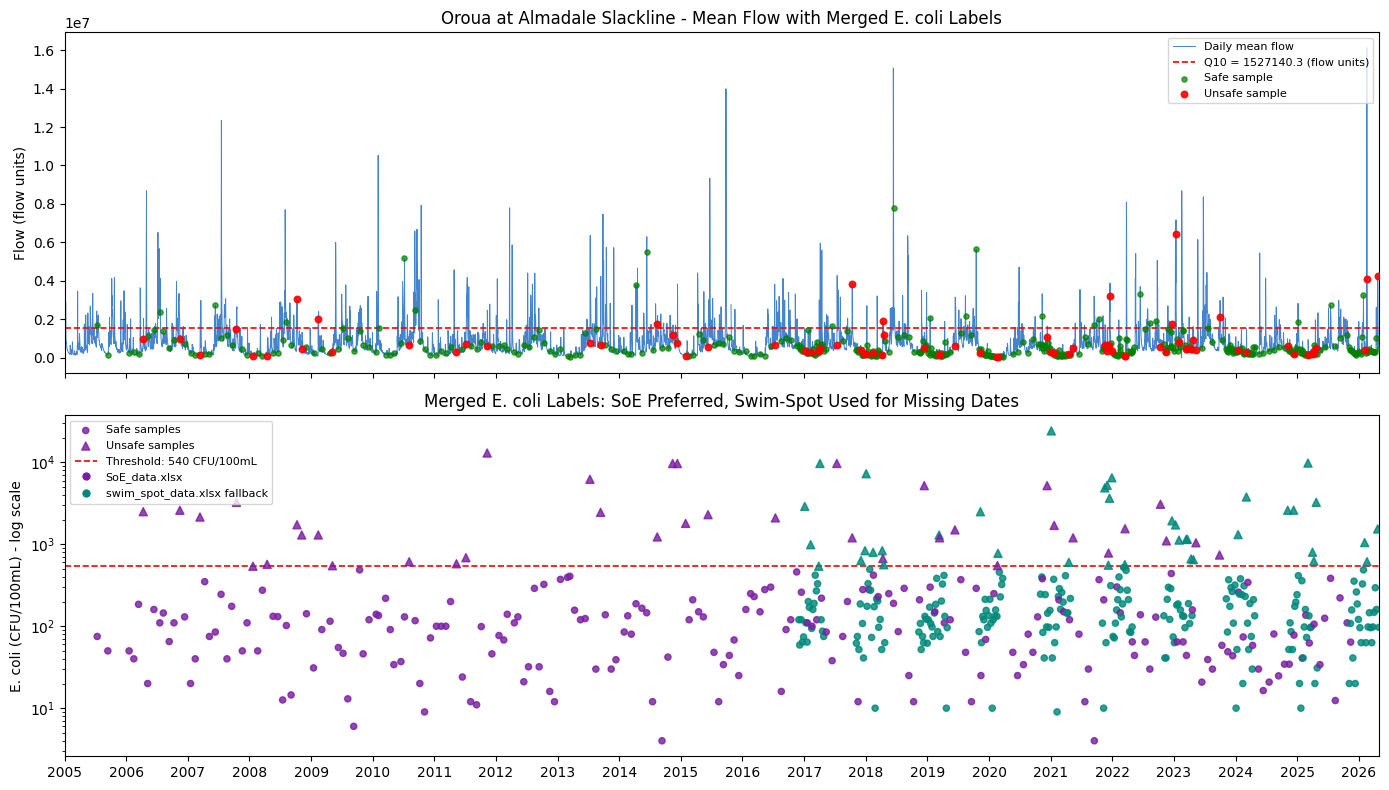

Section 8 OK - Saved: C:/Users/mfg0631/OneDrive - AUT University/SafeSwim/preprocessing_validation.png


In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x_min = pd.Timestamp(START_DATE)
x_max = pd.Timestamp(END_DATE)

# --- Panel 1: Almadale Slackline mean flow with Q10 threshold and sample labels ---
ax1 = axes[0]
flow_series = df_daily['flow_almadale_mean']
ax1.plot(flow_series.index, flow_series.values,
         color='#1565C0', linewidth=0.7, alpha=0.8, label='Daily mean flow')
ax1.axhline(q90, color='red', linestyle='--', linewidth=1.2,
            label=f'Q10 = {q90:.1f} (flow units)')

safe_days   = df_labelled.loc[df_labelled['label'] == 0, 'flow_almadale_mean']
unsafe_days = df_labelled.loc[df_labelled['label'] == 1, 'flow_almadale_mean']
ax1.scatter(safe_days.index,   safe_days.values,
            color='green', s=14, zorder=5, alpha=0.7, label='Safe sample')
ax1.scatter(unsafe_days.index, unsafe_days.values,
            color='red',   s=22, zorder=6, alpha=0.9, label='Unsafe sample')

ax1.set_xlim(x_min, x_max)
ax1.set_ylabel('Flow (flow units)')
ax1.set_title('Oroua at Almadale Slackline - Mean Flow with Merged E. coli Labels')
ax1.legend(fontsize=8, loc='upper right')

# --- Panel 2: E. coli values over time, coloured by selected label source ---
ax2 = axes[1]
source_colours = ecoli_selected.loc[df_labelled.index, 'source'].map({
    'SoE_data.xlsx': '#7B1FA2',
    'swim_spot_data.xlsx': '#00897B',
})
label_markers = {0: 'o', 1: '^'}
for label_value, marker in label_markers.items():
    subset = df_labelled[df_labelled['label'] == label_value]
    ax2.scatter(
        subset.index,
        subset['ecoli_cfu'],
        c=source_colours.loc[subset.index],
        marker=marker,
        s=20 if label_value == 0 else 34,
        alpha=0.82,
        zorder=5,
        label='Safe samples' if label_value == 0 else 'Unsafe samples',
    )

ax2.axhline(ECOLI_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
            label=f'Threshold: {ECOLI_THRESHOLD:.0f} CFU/100mL')
ax2.set_yscale('log')
ax2.set_ylabel('E. coli (CFU/100mL) - log scale')
ax2.set_title('Merged E. coli Labels: SoE Preferred, Swim-Spot Used for Missing Dates')

from matplotlib.lines import Line2D
source_handles = [
    Line2D([0], [0], marker='o', color='w', label='SoE_data.xlsx',
           markerfacecolor='#7B1FA2', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='swim_spot_data.xlsx fallback',
           markerfacecolor='#00897B', markersize=7),
]
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles + source_handles, labels + [h.get_label() for h in source_handles],
           fontsize=8, loc='best')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
out_fig = f'{BASE}/preprocessing_validation.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Section 8 OK - Saved: {out_fig}")
